## Imports

In [103]:
import time
import math
import random
import copy
from collections import defaultdict
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from IPython.display import display

In [104]:
random.seed(42)
np.random.seed(42)

## Load Data

In [105]:
courses_raw = pd.read_csv("..\data\Ganjil\data_mk_DSI_semester_ganjil.csv")
rooms_df = pd.read_csv("..\data\Ruang Kuliah.csv")
labs_df = pd.read_csv("..\data\Laboratorium.csv")

courses_raw.columns = [c.strip() for c in courses_raw.columns]
rooms_df.columns = [c.strip() for c in rooms_df.columns]
labs_df.columns = [c.strip() for c in labs_df.columns]

In [106]:
def to_int_safe(x, default=0):
    if pd.isna(x):
        return default          # ← jika default=None, return None
    try:
        return int(float(x))
    except:
        return default


In [107]:
courses = {}

for idx, row in courses_raw.iterrows():
    key = f"{row.iloc[0]}__{idx}"

    courses[key] = {
        'kode': str(row.iloc[0]).strip(),
        'nama': str(row.iloc[1]).strip(),
        'prodi': str(row.iloc[2]).strip(),
        'prioritas': to_int_safe(row.iloc[3], default=999),
        'dosen': to_int_safe(row.iloc[5], default=None),  # ← None jika NaN
        'sks': to_int_safe(row.iloc[7]),
        'praktikum': to_int_safe(row.iloc[8])
    }

course_keys = list(courses.keys())

for key in course_keys[:4]:
    print(courses[key])


{'kode': 'CSD60706', 'nama': 'Administrasi Basis Data', 'prodi': 'Sistem Informasi', 'prioritas': 1, 'dosen': 72, 'sks': 3, 'praktikum': 1}
{'kode': 'CSD60706', 'nama': 'Administrasi Basis Data', 'prodi': 'Sistem Informasi', 'prioritas': 1, 'dosen': 102, 'sks': 3, 'praktikum': 1}
{'kode': 'CSD60706', 'nama': 'Administrasi Basis Data', 'prodi': 'Sistem Informasi', 'prioritas': 1, 'dosen': 75, 'sks': 3, 'praktikum': 1}
{'kode': 'CSD60706', 'nama': 'Administrasi Basis Data', 'prodi': 'Sistem Informasi', 'prioritas': 1, 'dosen': 91, 'sks': 3, 'praktikum': 1}


In [108]:
def parse_classroom(kode):
    m = re.match(r'([A-Z])(\d+)\.', kode)
    return {
        'kode_ruang': kode,
        'Gedung': m.group(1),
        'Lantai': int(m.group(2))
    }

class_rooms = [parse_classroom(k) for k in rooms_df.iloc[:,0].astype(str)]
class_rooms[:3]

[{'kode_ruang': 'F11.1', 'Gedung': 'F', 'Lantai': 11},
 {'kode_ruang': 'F11.3', 'Gedung': 'F', 'Lantai': 11},
 {'kode_ruang': 'F11.4', 'Gedung': 'F', 'Lantai': 11}]

In [109]:
lab_rooms = []

for _, row in labs_df.iterrows():
    lab_rooms.append({
        'kode_ruang': f"LAB-{int(row.iloc[0])}",
        'Gedung': 'G',
        'Lantai': 1
    })

lab_room_codes = {r['kode_ruang'] for r in lab_rooms}

lab_rooms[:3]

[{'kode_ruang': 'LAB-2', 'Gedung': 'G', 'Lantai': 1},
 {'kode_ruang': 'LAB-5', 'Gedung': 'G', 'Lantai': 1},
 {'kode_ruang': 'LAB-14', 'Gedung': 'G', 'Lantai': 1}]

## Timeslot generation

In [110]:
DAYS = ['Mon','Tue','Wed','Thu','Fri']

LECTURE_HOURS = list(range(7,16))    
PRACT_HOURS   = list(range(7,18))     

BREAKS = {
    'Mon': [[11, 12]],
    'Tue': [[11, 12]],
    'Wed': [[11, 12]],
    'Thu': [[11, 12]],
    'Fri': [[11, 13]]
}

available_slots = []
for d in DAYS:
    for h in PRACT_HOURS:
        blocked = False
        for b1,b2 in BREAKS[d]:
            if h >= b1 and h < b2:
                blocked = True
        if not blocked:
            available_slots.append((d,h))

SLOT_INDEX = {s:i for i,s in enumerate(available_slots)}


# Prefensi Waktu Mengajar

In [111]:
USE_PREFERENCE = False

DAY_MAP = {
    'Senin': 'Mon',  'Mon': 'Mon',
    'Selasa': 'Tue', 'Tue': 'Tue',
    'Rabu': 'Wed',   'Wed': 'Wed',
    'Kamis': 'Thu',  'Thu': 'Thu',
    'Jumat': 'Fri',  'Fri': 'Fri'
}

pref_df = pd.read_csv("..\data\Preferensi_Mengajar.csv")
pref_df.columns = [c.strip() for c in pref_df.columns]

pref_map = defaultdict(set)

for _, r in pref_df.iterrows():
    dosen = int(r['dosen'])
    hari = DAY_MAP[r['hari']]
    jam  = int(r['jam'])

    pref_map[dosen].add((hari, jam))

## Struktur Session

In [112]:
def make_empty_schedule():
    sched = {}
    for k in course_keys:
        sks = courses[k]['sks']
        pr  = courses[k]['praktikum']
        sessions = []

        if pr == 1:
            lecture_count = max(0, sks - 1)     # ← FIX: sks=1 → max(0,0)=0, tidak negatif
            for _ in range(lecture_count):
                sessions.append({'type':'lecture','slot':None,'room':None})
            sessions.append({'type':'practicum','slot':None,'room':None})
        else:
            for _ in range(sks):
                sessions.append({'type':'lecture','slot':None,'room':None})

        sched[k] = sessions
    return sched

# Kandidat Ruangan

In [113]:
room_candidates_per_course = {}

for k in course_keys:
    room_candidates_per_course[k] = {
        'lecture': [r['kode_ruang'] for r in class_rooms],
        'practicum': [r['kode_ruang'] for r in lab_rooms]
    }


# RANDOM & REPAIR

In [114]:
def random_schedule():
    sched = make_empty_schedule()

    for k, sessions in sched.items():
        for sess in sessions:
            # slot valid
            sess['slot'] = random.randint(0, len(available_slots)-1)

            # room valid sesuai tipe
            rlist = room_candidates_per_course[k][sess['type']]
            if rlist:
                sess['room'] = random.choice(rlist)
            else:
                sess['room'] = None

    return sched

In [115]:
def repair_schedule(schedule):
    used = set()
    for k, sessions in schedule.items():
        for s in sessions:
            if s['slot'] is None:
                s['slot'] = random.randint(0, len(available_slots)-1)
            if s['room'] is None:
                rlist = room_candidates_per_course[k][s['type']]
                s['room'] = random.choice(rlist)

            # Cek konflik, random ulang sampai tidak bentrok (max 10x)
            for _ in range(10):
                key = (s['slot'], s['room'])
                if key not in used:
                    break
                s['slot'] = random.randint(0, len(available_slots)-1)

            key = (s['slot'], s['room'])  # key TERBARU setelah loop
            used.add(key)
            
    return schedule

In [116]:
def random_neighbor(schedule):
    new = copy.deepcopy(schedule)
    k = random.choice(course_keys)
    i = random.randrange(len(new[k]))

    if random.random() < 0.5:
        new[k][i]['slot'] = random.randint(0, len(available_slots)-1)
    else:
        rlist = room_candidates_per_course[k][new[k][i]['type']]
        new[k][i]['room'] = random.choice(rlist)

    return new


## Fitness evaluation with heavy & light penalties

In [117]:
def evaluate_schedule_detailed(schedule):
    heavy = defaultdict(int)
    light = defaultdict(int)

    room_use  = defaultdict(list)
    dosen_use = defaultdict(list)
    dosen_sks = defaultdict(int)

    for k, sessions in schedule.items():
        mk = courses[k]

        if len(sessions) != mk['sks']:
            heavy['SKS_Tidak_Terpenuhi'] += 1

        if mk['dosen'] is not None:
            dosen_sks[mk['dosen']] += mk['sks']

        for sess in sessions:
            if sess['slot'] is None or sess['room'] is None:
                heavy['Tidak_Ada_Ruang'] += 1
                continue

            day, hour = available_slots[sess['slot']]

            # OUTSIDE TIME
            if sess['type'] == 'lecture'   and hour not in LECTURE_HOURS:
                heavy['Diluar_Waktu'] += 1
            if sess['type'] == 'practicum' and hour not in PRACT_HOURS:
                heavy['Diluar_Waktu'] += 1

            # ROOM TYPE
            if sess['type'] == 'lecture'   and sess['room'] in lab_room_codes:
                heavy['Lecture_Pakai_Lab'] += 1
            if sess['type'] == 'practicum' and sess['room'] not in lab_room_codes:
                heavy['Praktikum_Tanpa_Lab'] += 1

            room_use[(sess['slot'], sess['room'])].append(k)

            if mk['dosen'] is not None:
                dosen_use[(sess['slot'], mk['dosen'])].append(k)

    # ROOM CONFLICT
    for v in room_use.values():
        if len(v) > 1:
            heavy['Ruang_Bentrok'] += len(v) - 1

    # DOSEN CONFLICT
    for v in dosen_use.values():
        if len(v) > 1:
            heavy['Dosen_Bentrok'] += len(v) - 1

    # MIN DOSEN SKS
    for d, s in dosen_sks.items():
        if s < 4:
            heavy['Dosen_Kurang_4_SKS'] += 1

    # === LIGHT PENALTY ===
    for k, sessions in schedule.items():
        mk = courses[k]

        # PRIORITY
        light['Prioritas Mata Kuliah'] += mk['prioritas']

        for sess in sessions:
            if sess['slot'] is None:
                continue
            day, hour = available_slots[sess['slot']]

            # PREFERENSI WAKTU DOSEN (jika aktif)
            if USE_PREFERENCE:
                if mk['dosen'] is not None:
                    if (day, hour) not in pref_map.get(mk['dosen'], set()):
                        light['Preferensi waktu'] += 1

    total_heavy = sum(heavy.values())
    total_light = sum(light.values())

    return {
        'heavy_total'  : total_heavy,
        'light_total'  : total_light,
        'heavy_detail' : dict(heavy),
        'light_detail' : dict(light),
        'is_feasible'  : total_heavy == 0
    }

# Fitness Score

In [118]:
# def fitness_score(schedule):
#     ev = evaluate_schedule_detailed(schedule)

#     if ev['heavy_total'] > 0:
#         fitness = 1e-9
#     else:
#         fitness = 1.0 / (1.0 + ev['light_total'])

#     ev['fitness'] = fitness
#     return ev


In [119]:
def fitness_score(schedule):
    ev = evaluate_schedule_detailed(schedule)
    total_penalty = (ev['heavy_total'] * 1000) + ev['light_total']
    fitness = 1.0 / (1.0 + total_penalty)
    
    ev['fitness'] = fitness
    return ev

In [120]:
# def select_best_feasible(results):
#     feasible = [r for r in results if r['eval']['heavy_total'] == 0]
#     if feasible:
#         return max(feasible, key=lambda r: r['eval']['fitness'])
#     return max(results, key=lambda r: r['eval']['fitness'])


In [121]:
def select_best_feasible(results):
    return max(results, key=lambda r: r['eval']['fitness'])


In [122]:
def init_history():
    return {
        'fitness': [],
        'heavy_total': [],
        'light_detail': defaultdict(list)  
    }


## COA implementation

In [123]:
# -----------------------------------------------------------------------------
# FASE 1 - Kelompok 1: iguana = Xbest  (Eq. 4 paper)
# Setengah pertama populasi menyerang iguana di posisi TERBAIK
# -----------------------------------------------------------------------------
def coati_explore_best(curr, best):
    """
    Analog Eq. (4):
        X_new = X + rand * (iguana - I * X)
        di mana iguana = Xbest, I = round(1 + rand) ∈ {1, 2}
    Dalam ruang diskrit (slot & ruang), kita terjemahkan sebagai:
    - Jika I=1 → bergerak mendekati best (copy slot/room dari best)
    - Jika I=2 → bergerak menjauhi best (acak)
    """
    new = copy.deepcopy(curr)
    k = random.choice(course_keys)
    if not new[k]:
        return new
    i = random.randrange(len(new[k]))

    I = random.randint(1, 2)  # round(1 + rand) ∈ {1, 2}

    if I == 1:
        # Mendekati iguana (Xbest)
        new[k][i]['slot'] = best[k][i]['slot']
        new[k][i]['room'] = best[k][i]['room']
    else:
        # Menjauhi iguana → bergerak acak
        new[k][i]['slot'] = random.randint(0, len(available_slots) - 1)
        rlist = room_candidates_per_course[k][new[k][i]['type']]
        if rlist:
            new[k][i]['room'] = random.choice(rlist)

    return new

In [124]:
# -----------------------------------------------------------------------------
# FASE 1 - Kelompok 2: iguana = posisi RANDOM  (Eq. 5–6 paper)
# Setengah kedua populasi menyerang iguana di posisi acak
# -----------------------------------------------------------------------------
def coati_explore_random(curr):
    """
    Analog Eq. (5): iguana = lowerbound + rand*(upperbound - lowerbound)
    Analog Eq. (6):
        Jika fit(X) > fit(iguana):  X_new = X + rand*(iguana - I*X)
        Else:                        X_new = X + rand*(X - iguana)
    Dalam ruang diskrit:
    - Bangkitkan posisi iguana acak
    - Hitung fitness iguana
    - Bandingkan dengan fitness individu, lalu update arah gerakan
    """
    new = copy.deepcopy(curr)
    k = random.choice(course_keys)
    if not new[k]:
        return new
    i = random.randrange(len(new[k]))

    # Iguana di posisi random (Eq. 5)
    iguana_slot = random.randint(0, len(available_slots) - 1)
    rlist = room_candidates_per_course[k][new[k][i]['type']]
    iguana_room = random.choice(rlist) if rlist else new[k][i]['room']

    # Buat jadwal sementara untuk evaluasi iguana
    iguana_sched = copy.deepcopy(new)
    iguana_sched[k][i]['slot'] = iguana_slot
    iguana_sched[k][i]['room'] = iguana_room

    fit_curr = fitness_score(new)['fitness']
    fit_iguana = fitness_score(iguana_sched)['fitness']

    I = random.randint(1, 2)

    if fit_curr > fit_iguana:
        # Bergerak mendekati iguana (Eq. 6 baris pertama)
        if I == 1:
            new[k][i]['slot'] = iguana_slot
            new[k][i]['room'] = iguana_room
        else:
            new[k][i]['slot'] = random.randint(0, len(available_slots) - 1)
            if rlist:
                new[k][i]['room'] = random.choice(rlist)
    else:
        # Bergerak menjauhi iguana (Eq. 6 baris kedua)
        new[k][i]['slot'] = random.randint(0, len(available_slots) - 1)
        if rlist:
            new[k][i]['room'] = random.choice(rlist)

    return new

In [125]:
# -----------------------------------------------------------------------------
# FASE 2: Eksploitasi dengan area pencarian MENYEMPIT  (Eq. 8–10 paper)
# -----------------------------------------------------------------------------
def coati_exploit_local(curr, t):
    """
    Analog Eq. (8):  X_new = X + (1 - 2*rand) * (LO + rand*(HI - LO))
    Analog Eq. (9):  LO_LOCAL = lowerbound / t
    Analog Eq. (10): HI_LOCAL = upperbound / t

    Dalam ruang diskrit:
    - Perturb slot dengan delta yang SEMAKIN KECIL seiring t bertambah
    - max_perturb = max(1, floor(N_slots / t))
    - Batas local: slot ± max_perturb (di-clamp ke [0, N_slots-1])
    """
    new = copy.deepcopy(curr)
    k = random.choice(course_keys)
    if not new[k]:
        return new
    i = random.randrange(len(new[k]))

    n_slots = len(available_slots)

    # LO_LOCAL & HI_LOCAL menyempit seiring t  (Eq. 9-10)
    max_perturb = max(1, int(n_slots / t))

    curr_slot = new[k][i]['slot']

    # Perturb slot dengan noise lokal (Eq. 8)
    lo_local = max(0, curr_slot - max_perturb)
    hi_local = min(n_slots - 1, curr_slot + max_perturb)
    new[k][i]['slot'] = random.randint(lo_local, hi_local)

    return new

In [126]:
# -----------------------------------------------------------------------------
# MAIN COA LOOP - Sesuai struktur paper
# -----------------------------------------------------------------------------
def coati_optimization(iterations=300, pop_size=40):
    """
    Alur utama COA:
    1. Inisialisasi populasi & tentukan Xbest SEBELUM loop
    2. Per iterasi:
       a. Update Xbest
       b. Fase 1 Kelompok 1 (i = 0 .. N/2-1)  → explore ke Xbest
       c. Fase 1 Kelompok 2 (i = N/2 .. N-1)  → explore ke iguana random
       d. Fase 2 semua individu                → exploit lokal (area menyempit)
    3. Simpan history
    """
    # --- Inisialisasi ---
    population = [repair_schedule(random_schedule()) for _ in range(pop_size)]
    evals = [fitness_score(p) for p in population]

    # Tentukan best SEBELUM iterasi (bukan None)
    idx0 = int(np.argmax([e['fitness'] for e in evals]))
    best = copy.deepcopy(population[idx0])
    best_eval = evals[idx0]

    history = init_history()
    half = pop_size // 2
    start = time.time()

    for t in trange(1, iterations + 1, desc="COA"):

        # ── Update Xbest di awal iterasi ──────────────────────────────────
        idx = int(np.argmax([e['fitness'] for e in evals]))
        if evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(population[idx])
            best_eval = evals[idx]

        # ── FASE 1 Kelompok 1: iguana = Xbest (Eq. 4) ────────────────────
        for i in range(half):
            cand = coati_explore_best(population[i], best)
            cand = repair_schedule(cand)
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i]['fitness']:
                population[i] = cand
                evals[i] = ev

        # ── FASE 1 Kelompok 2: iguana = random (Eq. 5-6) ─────────────────
        for i in range(half, pop_size):
            cand = coati_explore_random(population[i])
            cand = repair_schedule(cand)
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i]['fitness']:
                population[i] = cand
                evals[i] = ev

        # ── FASE 2: Eksploitasi lokal menyempit (Eq. 8-10) ───────────────
        for i in range(pop_size):
            cand = coati_exploit_local(population[i], t)
            cand = repair_schedule(cand)
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i]['fitness']:
                population[i] = cand
                evals[i] = ev

        # ── Simpan best & history ─────────────────────────────────────────
        idx = int(np.argmax([e['fitness'] for e in evals]))
        if evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(population[idx])
            best_eval = evals[idx]

        history['fitness'].append(best_eval['fitness'])
        history['heavy_total'].append(best_eval['heavy_total'])
        for k, v in best_eval['light_detail'].items():
            history['light_detail'][k].append(v)

    return best, best_eval, {
        'history': history,
        'runtime_s': time.time() - start
    }


## GA implementation (baseline)

In [127]:
# def ga_local_exploit(child, global_best, prob=0.3):
#     if random.random() < prob:
#         return coati_exploit(child, global_best)
#     return child

In [128]:
# def ga_optimize(generations=200, pop_size=60, mut_prob=0.2):
#     pop = [repair_schedule(random_schedule()) for _ in range(pop_size)]
#     evals = [fitness_score(p) for p in pop]

#     history = init_history()
#     best = None
#     best_eval = None

#     start = time.time()

#     for _ in trange(generations, desc="GA"):
#         new_pop = []

#         while len(new_pop) < pop_size:
#             i,j = random.sample(range(pop_size),2)
#             parent = pop[i] if evals[i]['fitness'] > evals[j]['fitness'] else pop[j]
#             child = copy.deepcopy(parent)

#             if random.random() < mut_prob:
#                 child = random_neighbor(child)

#             child = repair_schedule(child)
#             new_pop.append(child)

#         pop = new_pop
#         evals = [fitness_score(p) for p in pop]

#         idx = np.argmax([e['fitness'] for e in evals])
#         if best is None or evals[idx]['fitness'] > best_eval['fitness']:
#             best = copy.deepcopy(pop[idx])
#             best_eval = evals[idx]

#         history['fitness'].append(best_eval['fitness'])
#         history['heavy_total'].append(best_eval['heavy_total'])
#         for k,v in best_eval['light_detail'].items():
#             history['light_detail'][k].append(v)

#     return best, best_eval, {
#         'history': history,
#         'runtime_s': time.time() - start
#     }


## SA (Simulated Annealing) implementation

In [129]:
# def sa_neighbor(curr, best):
#     if random.random() < 0.6:
#         return coati_exploit(curr, best)
#     else:
#         return random_neighbor(curr)


In [130]:
# def sa_optimize(iterations=3000, T0=100, cooling=0.995):
#     curr = repair_schedule(random_schedule())
#     curr_eval = fitness_score(curr)

#     best = copy.deepcopy(curr)
#     best_eval = curr_eval

#     history = init_history()
#     T = T0
#     start = time.time()

#     for _ in trange(iterations, desc="SA"):
#         neigh = random_neighbor(curr)
#         neigh = repair_schedule(neigh)
#         ev = fitness_score(neigh)

#         delta = ev['fitness'] - curr_eval['fitness']
#         if delta > 0 or random.random() < math.exp(delta / T):
#             curr, curr_eval = neigh, ev

#             if curr_eval['fitness'] > best_eval['fitness']:
#                 best, best_eval = copy.deepcopy(curr), curr_eval

#         history['fitness'].append(best_eval['fitness'])
#         history['heavy_total'].append(best_eval['heavy_total'])
#         for k,v in best_eval['light_detail'].items():
#             history['light_detail'][k].append(v)

#         T *= cooling

#     return best, best_eval, {
#         'history': history,
#         'runtime_s': time.time() - start
#     }


## Run experiments

In [131]:
USE_PREFERENCE = False   
N_ITER = 300              
POP_COA = 40
POP_GA  = 40

SA_T0 = 100
SA_COOLING = 0.995

random.seed(42)
np.random.seed(42)


results = []

best, best_eval, meta = coati_optimization(
    iterations=N_ITER,
    pop_size=POP_COA
)

results.append({
    'name': 'COA',
    'schedule': best,
    'eval': best_eval,
    'history': meta['history'],
    'runtime': meta['runtime_s']
})


# best, best_eval, meta = ga_optimize(
#     generations=N_ITER,
#     pop_size=POP_GA
# )

# results.append({
#     'name': 'GA',
#     'schedule': best,
#     'eval': best_eval,
#     'history': meta['history'],
#     'runtime': meta['runtime_s']
# })


# best, best_eval, meta = sa_optimize(
#     iterations=N_ITER,
#     T0=SA_T0,
#     cooling=SA_COOLING
# )

# results.append({
#     'name': 'SA',
#     'schedule': best,
#     'eval': best_eval,
#     'history': meta['history'],
#     'runtime': meta['runtime_s']
# })


print("=== EXPERIMENT FINISHED ===")
for r in results:
    print(f"{r['name']:>4} | runtime={r['runtime']:.2f}s | fitness={r['eval']['fitness']:.6f}")


COA: 100%|██████████| 300/300 [05:46<00:00,  1.15s/it]

=== EXPERIMENT FINISHED ===
 COA | runtime=346.34s | fitness=0.000002


## Comparative evaluation & visualizations

In [132]:
rows = []

for r in results:
    rows.append({
        'Algorithm': r['name'],
        'Best Fitness': r['eval']['fitness'],
        'Heavy Penalty': r['eval']['heavy_total'],
        'Light Penalty': r['eval']['light_total'],
        'Feasible': r['eval']['is_feasible'],
        'Runtime (sec)': round(r['runtime'], 2)
    })

df_compare = pd.DataFrame(rows)
df_compare = df_compare.sort_values(
    by=['Feasible', 'Best Fitness'],
    ascending=[False, False]
)

display(df_compare)


,Algorithm,Best Fitness,Heavy Penalty,Light Penalty,Feasible,Runtime (sec)
0,COA,0.000002,519,566,False,346.34


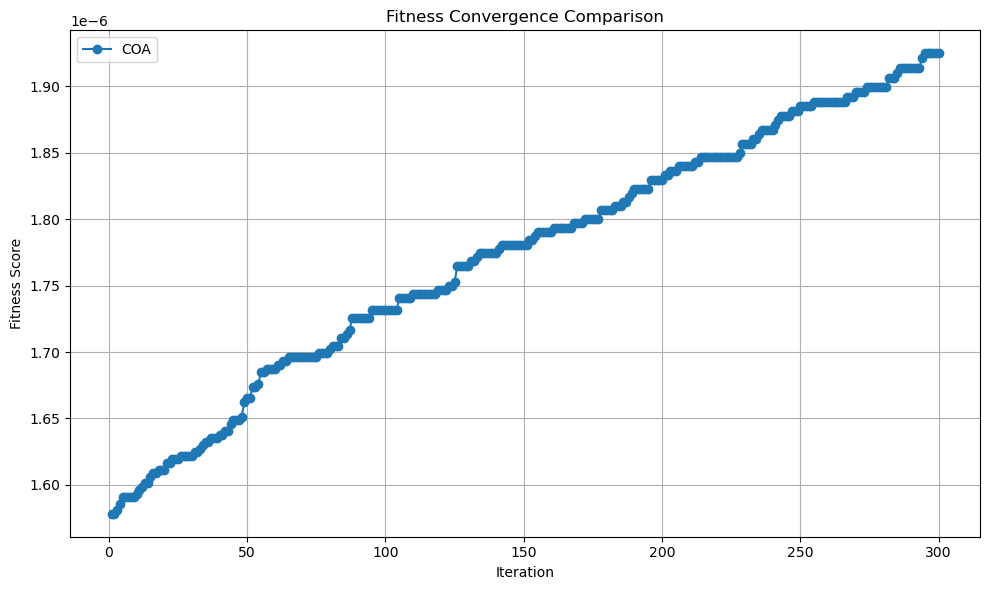

In [133]:
plt.figure(figsize=(10,6))

for r in results:
    if r['history']['fitness']:
        plt.plot(
            range(1, len(r['history']['fitness'])+1),
            r['history']['fitness'],
            label=r['name'],
            marker='o'
        )

plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.title("Fitness Convergence Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Save summary and representative schedule CSVs

In [134]:
def save_all_results_to_single_txt(results, filename):
    with open(filename, 'w') as f:                        # buka sekali untuk write
        f.write("=== SUMMARY REPORT - OPTIMIZATION RESULTS ===\n")
        f.write(f"Total Algorithms Tested: {len(results)}\n")
        f.write("=" * 45 + "\n\n")

        for i, result in enumerate(results):              # ← for di DALAM with
            f.write(f"--- RESULT #{i+1}: {result['name']} ---\n")
            f.write(f"Best Fitness : {result['eval']['fitness']:.6f}\n")
            f.write(f"Runtime      : {result['runtime']:.2f} sec\n")
            f.write(f"Status       : {'FEASIBLE' if result['eval']['is_feasible'] else 'NOT FEASIBLE'}\n")
            f.write(f"Heavy Penalty: {result['eval']['heavy_total']}\n")
            f.write(f"Light Penalty: {result['eval']['light_total']}\n\n")

            f.write("=== HEAVY DETAIL ===\n")
            if result['eval']['heavy_detail']:
                for k, v in result['eval']['heavy_detail'].items():
                    f.write(f"  - {k}: {v}\n")
            else:
                f.write("  No heavy penalties.\n")

            f.write("\n=== LIGHT DETAIL ===\n")
            if result['eval']['light_detail']:
                for k, v in result['eval']['light_detail'].items():
                    f.write(f"  - {k}: {v}\n")
            else:
                f.write("  No light penalties.\n")

            f.write("\n" + "=" * 45 + "\n\n")

filename = "all_reports_Gabungan.txt"
save_all_results_to_single_txt(results, filename)
print(f"Laporan lengkap dengan Fitness Score berhasil disimpan ke {filename}")

Laporan lengkap dengan Fitness Score berhasil disimpan ke all_reports_Gabungan.txt


In [135]:
rows = []

for r in results:
    sched = r['schedule']
    for k, sessions in sched.items():
        for sess in sessions:
            day, hour = available_slots[sess['slot']]
            rows.append({
                'Algorithm': r['name'],
                'Hari': day,
                'Jam': hour,
                'Prodi': courses[k]['prodi'],
                'Kode_MK': courses[k]['kode'],
                'Nama_MK': courses[k]['nama'],
                'Jenis': sess['type'],
                'Ruang': sess['room'],
                'Dosen': courses[k]['dosen'],
                'Fitness': r['eval']['fitness'],
                'Heavy_Total': r['eval']['heavy_total'],
                'Light_Total': r['eval']['light_total'],
                'Feasible': r['eval']['is_feasible']
            })

df_schedule_all = pd.DataFrame(rows)
df_schedule_all.to_csv("Gabungan_Schedules.csv", index=False)

# UJI NORMALITAS (SHAPIRO–WILK)

In [136]:
from scipy.stats import shapiro

fitness_values = [r['eval']['light_total'] for r in results]  # ambil semua, bukan filter

if len(fitness_values) < 3:
    print("Data tidak cukup untuk uji normalitas (minimal 3 sampel)")
else:
    stat, p = shapiro(fitness_values)
    print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.4f}")
    print("Normal" if p > 0.05 else "Tidak normal")


Data tidak cukup untuk uji normalitas (minimal 3 sampel)
